In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv(
    "exoplanet_data.csv",
    sep=",",
    comment="#" 
)

In [6]:
print(df.shape)     
print(df.columns.tolist())
print("Do not understand: pl_insolerr, ttv_flag, sy_vmag, sy_kmag, pl_insol")

(567, 92)
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_

In [ ]:
'''
--- TABLE LABELS ---

Planet Name: pl_name - most common name for the planet
Host Name: hostname - star host name
Discovery Method: discoverymethod
Spectral Type: st_spectype 
Equilibrium Temp: pl_eqt
Planet Mass or Mass*sin(i):
pl_masse for earth mass, - planet mass in earth masses
pl_massj for jupiter mass - // in jupier masses
pl_msinie for mass sini earth - min mass of planet measured by radial velocity, in earth masses
pl_msinij for sini j - //, in jupiter masses


'''

In [9]:
rdf = df[['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt','pl_bmassj']]

In [10]:
print(df["discoverymethod"].value_counts())
'''
7 different types of discovery methods
Most: Transit; Least: Disk Kinematics
Transit: detects dips in a star's lightcurve when a planet passes in front of it
Radial velocity: measures small wobbles in a star's motion caused by the gravitational pull of an orbiting planet
Direct imaging: takes actual pictures of planets
Microlensing: when a foreground star and planet bends and magnifies light from a background star, we can deduce that there is a point mass causing this from images
TTV: observes changes in timing between transits; small deviations are caused by gravitational interactions between multiple planets
ETC: the same as TTV?
Disk Kinematics: how gas and dust in a protoplanetary disk move around a star and measuring the velocity to discover disturbances which is usually evidence of a hidden planet


'''

discoverymethod
Transit                      388
Radial Velocity              107
Microlensing                  61
Imaging                        5
Transit Timing Variations      3
Eclipse Timing Variations      2
Disk Kinematics                1
Name: count, dtype: int64


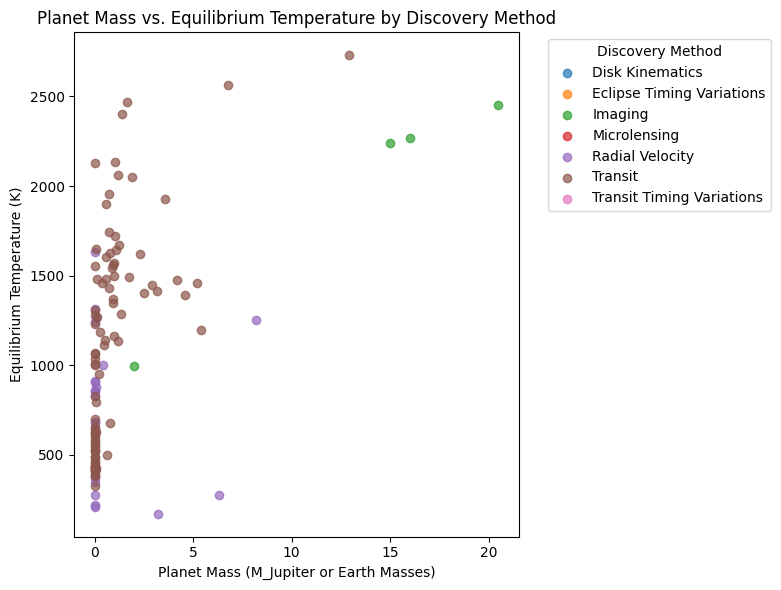

In [17]:
plt.figure(figsize=(8, 6))

for method, group in df.groupby("discoverymethod"):
    plt.scatter(
        group["pl_bmassj"],          
        group["pl_eqt"],           
        label=method,
        alpha=0.7                   
    )

plt.title("Planet Mass vs. Equilibrium Temperature by Discovery Method")
plt.xlabel("Planet Mass (M_Jupiter or Earth Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

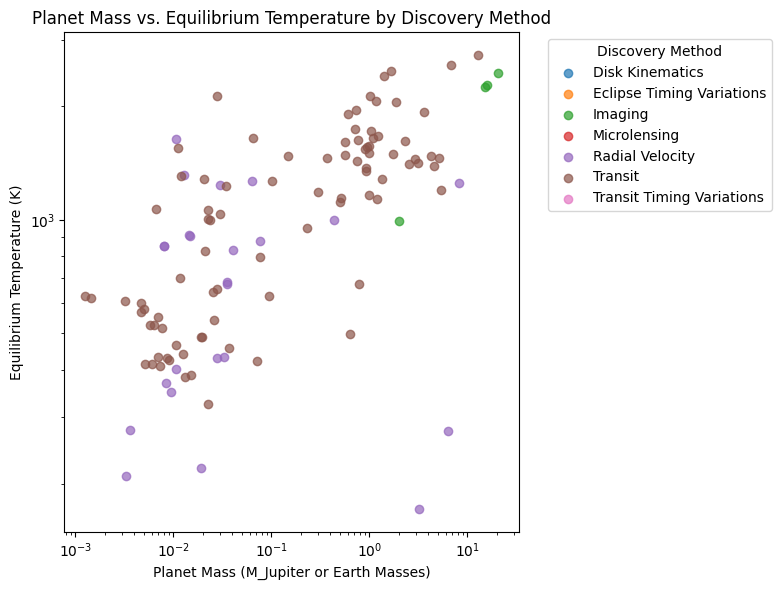

In [18]:
plt.figure(figsize=(8, 6))

for method, group in df.groupby("discoverymethod"):
    plt.scatter(
        group["pl_bmassj"],          
        group["pl_eqt"],           
        label=method,
        alpha=0.7                   
    )


plt.xscale("log")
plt.yscale("log")

plt.title("Planet Mass vs. Equilibrium Temperature by Discovery Method")
plt.xlabel("Planet Mass (M_Jupiter or Earth Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

In [19]:
print("Planets found by the imaging method are most likely to be large")

Planets found by the imaging method are most likely to be large


In [25]:
#massive planets

df_mp = df[rdf['pl_bmassj'] > 5]

coldest_index = df_mp["pl_eqt"].idxmin()
coldest_planet = df_mp.loc[df_mp['pl_eqt'].idxmin()]
print(coldest_planet)


print("Name:", coldest_planet["pl_name"])
print("Index:", coldest_index)
print("Equilibrium Temperature (K):", coldest_planet["pl_eqt"])
print("Mass (Jupiter Masses):", coldest_planet["pl_bmassj"])
print("Host Star Spectral Type:", coldest_planet["st_spectype"])



pl_name           eps Ind A b
hostname            eps Ind A
default_flag                1
sy_snum                     3
sy_pnum                     1
                     ...     
sy_gaiamagerr1       0.007374
sy_gaiamagerr2      -0.007374
rowupdate          2024-08-07
pl_pubdate            2024-09
releasedate        2024-08-07
Name: 566, Length: 92, dtype: object
Name: eps Ind A b
Index: 566
Equilibrium Temperature (K): 275.0
Mass (Jupiter Masses): 6.31
Host Star Spectral Type: K5 V


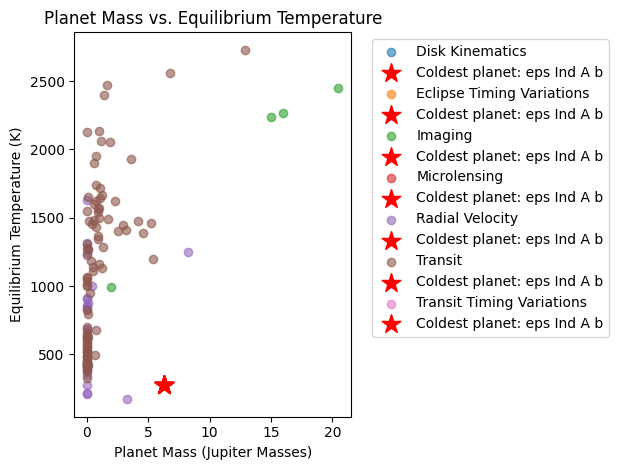

In [32]:
for method, group, in df.groupby('discoverymethod'):
    plt.scatter( group['pl_bmassj'], group['pl_eqt'], label = method, alpha=0.6)

    plt.scatter(
        coldest_planet['pl_bmassj'],
        coldest_planet['pl_eqt'], 
        color="red",
        marker="*",
        s=200,
        label=f"Coldest planet: {coldest_planet['pl_name']}"
    )

    
plt.title("Planet Mass vs. Equilibrium Temperature")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
    

In [ ]:
'''
Title: "A temperature super-Jupiter imaged with JWST in the mid-infared"

Summary: Researches use the JWST to capture direct images of a giant exoplanet orbiting Epsilon Indi A. This is a rare discovery because
unlike most directly imaged exoplanets, this planet orbits a old Sunlike star. The data implies that this is the only giant planet around this star
so it is designated Eps Ind A b

My answer matches the exoplanet. 

This planet is a rare discovery because this one orbits an old star and it is th eonly giant planet around this star. 

the mass and equilibrium temperature match what the paper reported. 
'''